<a href="https://colab.research.google.com/github/kashishgupta2911/SkinBuddy/blob/main/SCIN_Dataset.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **[SCIN (Skin Condition Image Network) Dataset](https://github.com/google-research-datasets/scin)**
* Collected from Google Search users in the US through a voluntary, consented image donation application
* Contains 5000+ volunteer contributions (10,000+ images) of common dermatology conditions
  * Contributions include images, self-reported demographic, history, and system information, and self-reported Fitzpatrick skin type (sFST)
  * Dermatologist labels of the skin condition and estimated Fitzpatrick skin type (eFST) and layperson estimated Monk Skin tone (eMST) labels are provided for each contribution
* Intended for health education and research, and to increase diversity of dermatology images
* [Dataset Documentation](https://https://github.com/google-research-datasets/scin/blob/main/dataset_schema.md)



**Task:**
* Work on data extrapolation with the datasets that we currently have
* Each individual works with a dataset, cleans it up, and sees what is useful


# **Loading the Data**
Taken from [scin_demo.ipynb](https://github.com/google-research-datasets/scin/blob/main/scin_demo.ipynb)

## Setup

In [2]:
#@title Install the required packages

!pip install matplotlib google-cloud-storage

In [3]:
#@title Imports

import collections
import copy
import hashlib
import io
import os
import subprocess
import textwrap
import time

from typing import List, Text

from PIL import Image

import numpy as np
import pandas as pd
import tabulate


import tensorflow as tf

import matplotlib.pyplot as plt

## Authenticate
The following cell is for Colab only. If running elsewhere, authenticate with the gcloud CLI.

In [4]:
from google.colab import auth

# Authenticate user for access. There will be a popup asking you to sign in with your user and approve access.
auth.authenticate_user()

## Configuration

In [5]:
#@title Global params

class Globals:
  # GCP project with GCS bucket of interest
  gcp_project = 'dx-scin-public' #@param

  # GCS bucket with data to read
  gcs_bucket_name = 'dx-scin-public-data' #@param

  # CSV of case metadata to read
  cases_csv = 'dataset/scin_cases.csv' #@param

  # CSV of label metadata to read
  labels_csv = 'dataset/scin_labels.csv' #@param

  # Images directory
  gcs_images_dir = 'dataset/images/' #@param

  ### Key column names
  image_path_columns = ['image_1_path', 'image_2_path', 'image_3_path']
  weighted_skin_condition_label = "weighted_skin_condition_label"
  skin_condition_label = "dermatologist_skin_condition_on_label_name"

  ###### Formed during execution:

  # Client for querying GCS
  gcs_storage_client = None

  # Bucket object for loading files
  gcs_bucket = None

  # pd.DataFrame for the loaded metadata_csv
  cases_df = None

  # pd.DataFrame for the loaded labels_csv
  cases_and_labels_df = None

print(f'GCS bucket name: {Globals.gcs_bucket_name}')
print(f'cases_csv: {Globals.cases_csv}')
print(f'labels_csv: {Globals.labels_csv}')
print(f'images dir: {Globals.gcs_images_dir}')

GCS bucket name: dx-scin-public-data
cases_csv: dataset/scin_cases.csv
labels_csv: dataset/scin_labels.csv
images dir: dataset/images/


## Load Dataset

In [6]:
#@title Create a dataframe that contains the metadata and condition labels

from google.cloud import storage

def list_blobs(storage_client, bucket_name):
  """Helper to list blobs in a bucket (useful for debugging)."""
  blobs = storage_client.list_blobs(bucket_name)
  for blob in blobs:
    print(blob)

def initialize_df_with_metadata(bucket, csv_path):
  """Loads the given CSV into a pd.DataFrame."""
  df = pd.read_csv(io.BytesIO(bucket.blob(csv_path).download_as_string()), dtype={'case_id': str})
  df['case_id'] = df['case_id'].astype(str)
  return df

def augment_metadata_with_labels(df, bucket, csv_path):
  """Loads the given CSV into a pd.DataFrame."""
  labels_df = pd.read_csv(io.BytesIO(bucket.blob(csv_path).download_as_string()), dtype={'case_id': str})
  labels_df['case_id'] = labels_df['case_id'].astype(str)
  merged_df = pd.merge(df, labels_df, on='case_id')
  return merged_df

Globals.gcs_storage_client = storage.Client(Globals.gcp_project)
Globals.gcs_bucket = Globals.gcs_storage_client.bucket(
    Globals.gcs_bucket_name
)
Globals.cases_df = initialize_df_with_metadata(Globals.gcs_bucket, Globals.cases_csv)
Globals.cases_and_labels_df = augment_metadata_with_labels(Globals.cases_df, Globals.gcs_bucket, Globals.labels_csv)
print(len(Globals.cases_and_labels_df))


5033


In [7]:
Globals.cases_and_labels_df.columns

Index(['case_id', 'source', 'release', 'year', 'age_group', 'sex_at_birth',
       'fitzpatrick_skin_type',
       'race_ethnicity_american_indian_or_alaska_native',
       'race_ethnicity_asian', 'race_ethnicity_black_or_african_american',
       'race_ethnicity_hispanic_latino_or_spanish_origin',
       'race_ethnicity_middle_eastern_or_north_african',
       'race_ethnicity_native_hawaiian_or_pacific_islander',
       'race_ethnicity_white', 'race_ethnicity_other_race',
       'race_ethnicity_prefer_not_to_answer', 'textures_raised_or_bumpy',
       'textures_flat', 'textures_rough_or_flaky', 'textures_fluid_filled',
       'body_parts_head_or_neck', 'body_parts_arm', 'body_parts_palm',
       'body_parts_back_of_hand', 'body_parts_torso_front',
       'body_parts_torso_back', 'body_parts_genitalia_or_groin',
       'body_parts_buttocks', 'body_parts_leg', 'body_parts_foot_top_or_side',
       'body_parts_foot_sole', 'body_parts_other',
       'condition_symptoms_bothersome_appearan

In [8]:
Globals.cases_and_labels_df.sample(1)

,case_id,source,release,year,age_group,sex_at_birth,fitzpatrick_skin_type,race_ethnicity_american_indian_or_alaska_native,race_ethnicity_asian,race_ethnicity_black_or_african_american,...,dermatologist_gradable_for_fitzpatrick_skin_type_1,dermatologist_gradable_for_fitzpatrick_skin_type_2,dermatologist_gradable_for_fitzpatrick_skin_type_3,dermatologist_fitzpatrick_skin_type_label_1,dermatologist_fitzpatrick_skin_type_label_2,dermatologist_fitzpatrick_skin_type_label_3,gradable_for_monk_skin_tone_india,gradable_for_monk_skin_tone_us,monk_skin_tone_label_india,monk_skin_tone_label_us
584,-2923974706399124170,SCIN,1.0.0,2023,AGE_UNKNOWN,OTHER_OR_UNSPECIFIED,FST4,NaN,NaN,NaN,...,YES,NaN,NaN,FST3,NaN,NaN,True,True,2.0,1.0


## Get familiar with the data

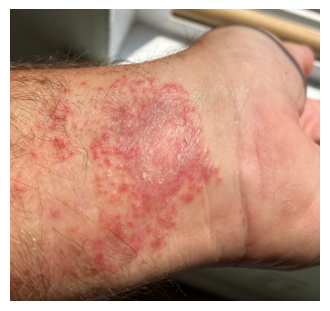

{'Allergic Contact Dermatitis': 0.55, 'Infected eczema': 0.23, 'Scabies': 0.23}


In [9]:
#@title Display the images for a case (and condition labels, optionally)
import random

import io
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt

def display_image(bucket, image_path):
  image = Image.open(io.BytesIO(bucket.blob(image_path).download_as_string()))
  figure_size=4
  f, axarr = plt.subplots(1, 1, figsize = (figure_size, figure_size))
  axarr.imshow(image, cmap='gray')
  axarr.axis('off')
  plt.show()

def display_images_for_case(df, case_id="", print_condition_labels=True):
  # Use a random case if none is provided:
  if case_id:
    matched_df = df[df['case_id'] == case_id]
  else:
    matched_df = df.sample(1)

  image_paths = matched_df[Globals.image_path_columns].values.tolist()[0]
  for path in image_paths:
    if isinstance(path, str):
      display_image(Globals.gcs_bucket, path)
  if print_condition_labels:
    condition_labels = matched_df[[Globals.weighted_skin_condition_label]].values.tolist()[0]
    for label in condition_labels:
      if isinstance(label, str):
        print(label)

# display_images_for_case(Globals.cases_and_labels_df, "-1000600354148496558")
display_images_for_case(Globals.cases_and_labels_df)

In [10]:
#@title Print metadata stats
def print_metadata_stats(df: pd.DataFrame) -> None:
  print(f'Num cases: {len(df)}')

  # Number of cases with 1, 2, or 3 images
  image_1_cnt = df["image_1_path"].count()
  image_2_cnt = df["image_2_path"].count()
  image_3_cnt = df["image_3_path"].count()
  print(f'Num cases with image_1_path set: {image_1_cnt}')
  print(f'Num cases with image_2_path set: {image_2_cnt}')
  print(f'Num cases with image_3_path set: {image_3_cnt}')
  print(f'Total images: {image_1_cnt + image_2_cnt + image_3_cnt}')

  # Sex at birth:
  print('\nSelf-reported Sex at Birth:')
  sab = collections.Counter(df['sex_at_birth'].dropna())
  total = sum(sab.values())
  for k in sorted(sab):
    print(f'  {k} {sab[k]} ({100.0*sab[k]/total:.1f}%)')

  # FST distribution:
  print('\nSelf-reported Fitzpatrick Skin Type:')
  fst = collections.Counter(df['fitzpatrick_skin_type'].dropna())
  total = sum(fst.values())
  for k in sorted(fst):
    print(f'  {k} {fst[k]} ({100.0*fst[k]/total:.1f}%)')


print_metadata_stats(Globals.cases_and_labels_df)

Num cases: 5033
Num cases with image_1_path set: 5033
Num cases with image_2_path set: 3085
Num cases with image_3_path set: 2289
Total images: 10407

Self-reported Sex at Birth:
  FEMALE 1666 (33.1%)
  MALE 807 (16.0%)
  OTHER_OR_UNSPECIFIED 2559 (50.9%)

Self-reported Fitzpatrick Skin Type:
  FST1 188 (7.5%)
  FST2 542 (21.7%)
  FST3 661 (26.4%)
  FST4 427 (17.1%)
  FST5 214 (8.5%)
  FST6 143 (5.7%)
  NONE_IDENTIFIED 328 (13.1%)


In [11]:
#@title Add combined_race_ethnicity column

def merge_race_ethnicity_columns(row):
  combined = []
  for col in row.keys():
    if col.startswith("race_ethnicity_") and row[col] == 'YES':
      combined.append(col[len("race_ethnicity_"):])
  return ",".join(combined)

Globals.cases_and_labels_df["combined_race_ethnicity"] = Globals.cases_and_labels_df.apply(merge_race_ethnicity_columns, axis=1)
Globals.cases_and_labels_df[["case_id", "combined_race_ethnicity"]]

,case_id,combined_race_ethnicity
0,-1000600354148496558,
1,-1002039107727665188,
2,-1003358831658393077,hispanic_latino_or_spanish_origin
3,-1003826561155964328,
4,-1003844406100696311,white
...,...,...
5028,973759811984683137,two_or_more_after_mitigation
5029,973872028150293734,
5030,983265958160210646,black_or_african_american
5031,995820220956352730,two_or_more_after_mitigation


In [12]:
#@title Print race/ethnicity distribution

def print_race_ethnicity_dist(df):
  c = collections.Counter(df['combined_race_ethnicity'].dropna())
  total = sum(c.values())
  for k in sorted(c):
    if not k:
      k = 'unspecified'
    print(f'  {k}: {c[k]} ({100.0*c[k]/total:.1f}%)')

print_race_ethnicity_dist(Globals.cases_and_labels_df)

  unspecified: 0 (0.0%)
  american_indian_or_alaska_native: 48 (1.0%)
  american_indian_or_alaska_native,white: 25 (0.5%)
  asian: 85 (1.7%)
  asian,white: 11 (0.2%)
  black_or_african_american: 267 (5.3%)
  black_or_african_american,hispanic_latino_or_spanish_origin: 11 (0.2%)
  black_or_african_american,white: 20 (0.4%)
  hispanic_latino_or_spanish_origin: 224 (4.5%)
  hispanic_latino_or_spanish_origin,white: 55 (1.1%)
  middle_eastern_or_north_african: 7 (0.1%)
  native_hawaiian_or_pacific_islander: 4 (0.1%)
  other_race: 16 (0.3%)
  prefer_not_to_answer: 34 (0.7%)
  two_or_more_after_mitigation: 83 (1.6%)
  white: 1762 (35.0%)


## Skin Condition label information

In [13]:
#@title Print condition distribution

def print_condition_distribution(df, top_n_conditions=50):
  # Any condition that shows up in a label
  condition_ctr = collections.Counter()
  print(f'Distribution of conditions in "{Globals.skin_condition_label}" column:')
  for entry in df[Globals.skin_condition_label].dropna():
    condition_ctr.update(eval(entry))
  for condition, cnt in condition_ctr.most_common()[:top_n_conditions]:
    print(f'  {condition}: {cnt}')
  print(f'Distribution of conditions in "{Globals.weighted_skin_condition_label}" column:')
  weighted_condition_ctr = collections.Counter()
  for entry in df[Globals.weighted_skin_condition_label].dropna():
    weighted_condition_ctr.update(eval(entry).keys())
  for condition, cnt in weighted_condition_ctr.most_common()[:top_n_conditions]:
    print(f'  {condition}: {cnt}')

print_condition_distribution(Globals.cases_and_labels_df)

Distribution of conditions in "dermatologist_skin_condition_on_label_name" column:
  Eczema: 1211
  Allergic Contact Dermatitis: 952
  Insect Bite: 449
  Urticaria: 377
  Psoriasis: 348
  Folliculitis: 297
  Irritant Contact Dermatitis: 254
  Tinea: 232
  Herpes Zoster: 157
  Drug Rash: 156
  Herpes Simplex: 152
  Impetigo: 124
  Acute dermatitis, NOS: 124
  Hypersensitivity: 115
  Acne: 109
  Pigmented purpuric eruption: 108
  Leukocytoclastic Vasculitis: 105
  Lichen planus/lichenoid eruption: 94
  Pityriasis rosea: 89
  Viral Exanthem: 87
  Lichen Simplex Chronicus: 85
  Stasis Dermatitis: 83
  Keratosis pilaris: 72
  CD - Contact dermatitis: 70
  Scabies: 68
  Tinea Versicolor: 68
  Granuloma annulare: 65
  Molluscum Contagiosum: 64
  Rosacea: 57
  Abrasion, scrape, or scab: 51
  O/E - ecchymoses present: 51
  Seborrheic Dermatitis: 50
  Acute and chronic dermatitis: 47
  Photodermatitis: 45
  Cellulitis: 45
  Abscess: 43
  Verruca vulgaris: 42
  SCC/SCCIS: 38
  Purpura: 38
  Inter

In [14]:
#@title Print column names
print(Globals.cases_and_labels_df.columns)

Index(['case_id', 'source', 'release', 'year', 'age_group', 'sex_at_birth',
       'fitzpatrick_skin_type',
       'race_ethnicity_american_indian_or_alaska_native',
       'race_ethnicity_asian', 'race_ethnicity_black_or_african_american',
       'race_ethnicity_hispanic_latino_or_spanish_origin',
       'race_ethnicity_middle_eastern_or_north_african',
       'race_ethnicity_native_hawaiian_or_pacific_islander',
       'race_ethnicity_white', 'race_ethnicity_other_race',
       'race_ethnicity_prefer_not_to_answer', 'textures_raised_or_bumpy',
       'textures_flat', 'textures_rough_or_flaky', 'textures_fluid_filled',
       'body_parts_head_or_neck', 'body_parts_arm', 'body_parts_palm',
       'body_parts_back_of_hand', 'body_parts_torso_front',
       'body_parts_torso_back', 'body_parts_genitalia_or_groin',
       'body_parts_buttocks', 'body_parts_leg', 'body_parts_foot_top_or_side',
       'body_parts_foot_sole', 'body_parts_other',
       'condition_symptoms_bothersome_appearan

## Display distributions of self-reported condition info

Distribution data: {'arm': 1707, 'leg': 1694, 'torso_front': 795, 'head_or_neck': 737, 'torso_back': 652, 'other': 543, 'back_of_hand': 521, 'foot_top_or_side': 415, 'buttocks': 391, 'genitalia_or_groin': 222, 'palm': 215, 'foot_sole': 104}


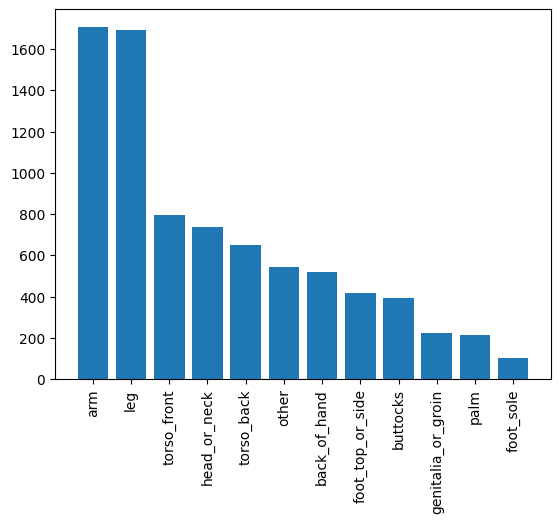

In [15]:
#@title Display body part distribution

def get_distribution_columns(df, prefix):
  cols = [c for c in df.columns if c.startswith(prefix)]
  dist = collections.Counter()
  for c in cols:
    name = c[len(prefix):]
    val = sum(df[c] == "YES")
    dist[name] = val
  return dist

def get_distribution_and_display(df, prefix):
  ctr = get_distribution_columns(df, prefix)
  dist = dict(ctr.most_common())
  print(f'Distribution data: {dist}')
  names = list(dist.keys())
  counts = list(dist.values())
  plt.bar(names, counts)
  plt.xticks(rotation=90)  # Rotate labels by 90 degrees
  plt.show()

# Distribution data: {'arm': 1707, 'leg': 1694, 'torso_front': 795, 'head_or_neck': 737, 'torso_back': 652, 'other': 543, 'back_of_hand': 521, 'foot_top_or_side': 415, 'buttocks': 391, 'genitalia_or_groin': 222, 'palm': 215, 'foot_sole': 104}
get_distribution_and_display(Globals.cases_and_labels_df, "body_parts_")

Distribution data: {'raised_or_bumpy': 2915, 'rough_or_flaky': 1032, 'flat': 822, 'fluid_filled': 629}


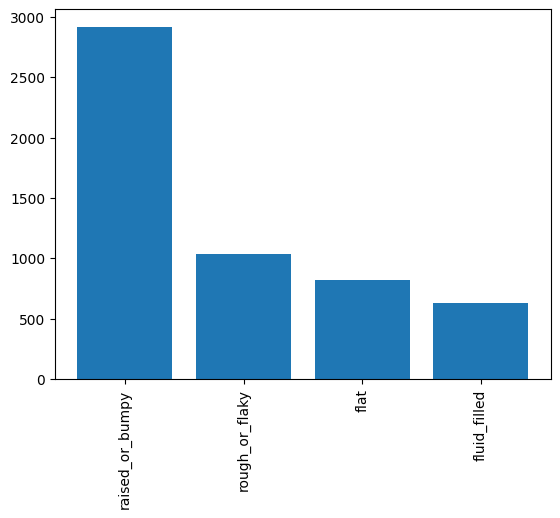

In [16]:
#@title Display texture distribution
get_distribution_and_display(Globals.cases_and_labels_df, "textures_")

Distribution data: {'itching': 2712, 'bothersome_appearance': 1530, 'increasing_size': 1013, 'burning': 988, 'pain': 734, 'darkening': 385, 'no_relevant_experience': 308, 'bleeding': 225}


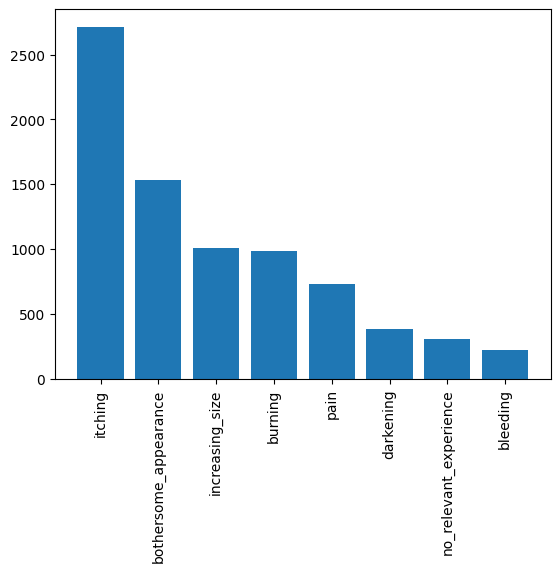

In [17]:
#@title Display condition symptom dist
get_distribution_and_display(Globals.cases_and_labels_df, "condition_symptoms_")

Distribution data: {'no_relevant_symptoms': 2841, 'fatigue': 415, 'joint_pain': 300, 'shortness_of_breath': 139, 'chills': 120, 'mouth_sores': 96, 'fever': 90}


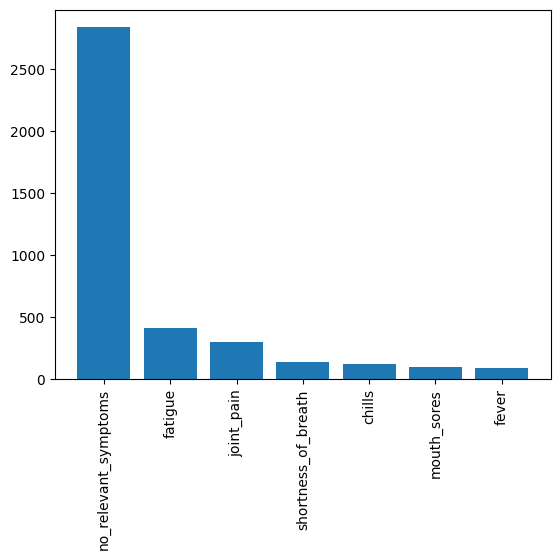

In [18]:
#@title Display other symptoms distribution
get_distribution_and_display(Globals.cases_and_labels_df, "other_symptoms_")





---





In [19]:
#@title Check for missing data

# Show all columns
pd.set_option('display.max_columns', None)

# Print number of missing values in each column
print(Globals.cases_and_labels_df.isnull().sum())

# Print rows with missing values
missing_rows = Globals.cases_and_labels_df[Globals.cases_and_labels_df.isnull().any(axis=1)]
# print(missing_rows)

case_id                               0
source                                0
release                               0
year                                  0
age_group                             1
                                     ..
gradable_for_monk_skin_tone_india    10
gradable_for_monk_skin_tone_us       10
monk_skin_tone_label_india           14
monk_skin_tone_label_us              28
combined_race_ethnicity               0
Length: 74, dtype: int64


# **Data Cleaning**
* drop rows with duplicate images
* drop duplicate rows
* drop rows with corrupted images

drop columns that might be irrelevant:
* source (keep) - note down and remove col
* release
* year - note down
* gradable (drop this col after removing rows where there is no dermatologist input?)

might drop these rows:
* rows with no skin condition labels ( dermatologist_skin_condition_on_label_name = [] )
* rows with no FST dermatologist label?
* rows with no monk skin tone dermatologist label?

standardize the values for these columns:
* make all columns with "gradable" in it have these values: "YES/NO" or "TRUE/FALSE"



In [22]:
import ast
from pathlib import Path
from PIL import Image

df_raw = Globals.cases_and_labels_df.copy()

# Settings (toggle as needed)
DROP_CASES_WITH_NO_SKIN_LABEL = True
REQUIRE_IMAGE_QUALITY_OK = True          # uses dermatologist_gradable_for_skin_condition_* votes
CHECK_CORRUPTED_IMAGES = False           # only works if image files are present locally
DEDUP_BY_IMAGE_HASH = False              # requires local images
IMAGES_ROOT = Path(".")                  # set to repo root if needed
OUT_DIR = Path("data/processed")
OUT_DIR.mkdir(parents=True, exist_ok=True)

# Helpers: parsing + normalizing
def parse_list_str(x):
    if pd.isna(x):
        return []
    try:
        v = ast.literal_eval(x) if isinstance(x, str) else x
        return v if isinstance(v, list) else []
    except Exception:
        return []

def parse_dict_str(x):
    if pd.isna(x):
        return {}
    try:
        v = ast.literal_eval(x) if isinstance(x, str) else x
        return v if isinstance(v, dict) else {}
    except Exception:
        return {}

def normalize_gradable_skin_condition(val):
    # Maps SCIN categories -> YES/NO/NaN
    if pd.isna(val):
        return np.nan
    if val == "NO_IMAGE_QUALITY_INSUFFICIENT":
        return "NO"
    if val in ["DEFAULT_YES_IMAGE_QUALITY_SUFFICIENT", "YES_IMAGE_QUALITY_SUFFICIENT_NO_DISCERNIBLE_PATHOLOGY"]:
        return "YES"
    return np.nan

def majority_yes(values):
    values = [v for v in values if pd.notna(v)]
    if len(values) == 0:
        return np.nan
    return "YES" if values.count("YES") >= values.count("NO") else "NO"

def safe_open_image(path: Path):
    # returns True if readable image
    try:
        with Image.open(path) as im:
            im.verify()
        return True
    except Exception:
        return False

def file_md5(path: Path, chunk_size=1024*1024):
    import hashlib
    h = hashlib.md5()
    with open(path, "rb") as f:
        for chunk in iter(lambda: f.read(chunk_size), b""):
            h.update(chunk)
    return h.hexdigest()

# 1) Parse labels + create primary label
df_raw["skin_condition_labels_list"] = df_raw["dermatologist_skin_condition_on_label_name"].apply(parse_list_str)
df_raw["skin_condition_confidence_list"] = df_raw["dermatologist_skin_condition_confidence"].apply(parse_list_str)
df_raw["weighted_skin_condition_dict"] = df_raw["weighted_skin_condition_label"].apply(parse_dict_str)

df_raw["skin_condition_label_count"] = df_raw["skin_condition_labels_list"].apply(len)

def get_primary_from_weights(d):
    if not isinstance(d, dict) or len(d) == 0:
        return None
    return max(d, key=d.get)

df_raw["primary_skin_condition"] = df_raw["weighted_skin_condition_dict"].apply(get_primary_from_weights)

# 2) Standardize gradable columns + aggregate votes
# skin condition image quality (derm 1-3 may be missing)
for c in ["dermatologist_gradable_for_skin_condition_1",
          "dermatologist_gradable_for_skin_condition_2",
          "dermatologist_gradable_for_skin_condition_3"]:
    df_raw[c + "_YN"] = df_raw[c].apply(normalize_gradable_skin_condition)

df_raw["skin_condition_gradable_majority"] = df_raw[
    ["dermatologist_gradable_for_skin_condition_1_YN",
     "dermatologist_gradable_for_skin_condition_2_YN",
     "dermatologist_gradable_for_skin_condition_3_YN"]
].apply(lambda r: majority_yes(list(r.values)), axis=1)

# Fitzpatrick gradable majority
fst_grad_cols = ["dermatologist_gradable_for_fitzpatrick_skin_type_1",
                 "dermatologist_gradable_for_fitzpatrick_skin_type_2",
                 "dermatologist_gradable_for_fitzpatrick_skin_type_3"]
df_raw["fst_gradable_majority"] = df_raw[fst_grad_cols].apply(lambda r: majority_yes(list(r.values)), axis=1)

# Monk gradable (already boolean) -> YES/NO
for c in ["gradable_for_monk_skin_tone_india", "gradable_for_monk_skin_tone_us"]:
    df_raw[c + "_YN"] = df_raw[c].map({True: "YES", False: "NO"}).fillna(np.nan)

# 3) Drop obvious duplicates at row level
n0 = len(df_raw)
df_raw = df_raw.drop_duplicates(subset=['case_id'])
n1 = len(df_raw)

# 4) Drop cases with no dermatologist skin condition label
if DROP_CASES_WITH_NO_SKIN_LABEL:
    df_raw = df_raw[df_raw["primary_skin_condition"].notna()].copy()

# Optionally require image quality OK (majority YES)
if REQUIRE_IMAGE_QUALITY_OK:
    df_raw = df_raw[df_raw["skin_condition_gradable_majority"] == "YES"].copy()

# 5) Expand to IMAGE-LEVEL table (recommended for training)
image_cols = [
    ("image_1_path", "image_1_shot_type", 1),
    ("image_2_path", "image_2_shot_type", 2),
    ("image_3_path", "image_3_shot_type", 3),
]

rows = []
for _, row in df_raw.iterrows():
    for p_col, s_col, idx in image_cols:
        p = row.get(p_col, np.nan)
        if pd.isna(p):
            continue
        new = row.to_dict()
        new["image_path"] = p
        new["shot_type"] = row.get(s_col, np.nan)
        new["image_index"] = idx
        rows.append(new)

df_img = pd.DataFrame(rows)

# 6) Drop duplicate image paths (simple)
df_img = df_img.drop_duplicates(subset=["image_path"])

# 7) Corrupted image check + hash dedupe (only if images are local)
if CHECK_CORRUPTED_IMAGES:
    exists = []
    readable = []
    for p in df_img["image_path"].tolist():
        full = IMAGES_ROOT / p
        exists.append(full.exists())
        readable.append(safe_open_image(full) if full.exists() else False)

    df_img["image_exists_local"] = exists
    df_img["image_readable"] = readable

    # Drop corrupted / missing local images (if you are training locally)
    df_img = df_img[df_img["image_readable"] == True].copy()

if DEDUP_BY_IMAGE_HASH and CHECK_CORRUPTED_IMAGES:
    hashes = []
    for p in df_img["image_path"].tolist():
        full = IMAGES_ROOT / p
        hashes.append(file_md5(full))
    df_img["image_md5"] = hashes
    df_img = df_img.drop_duplicates(subset=["image_md5"]).copy()

# 8) Drop columns you said are irrelevant (but keep source for provenance)
# Keep: case_id, source, age_group, sex_at_birth, body parts, textures, symptoms, skin tones, primary label
# Drop: release/year (park them if you want)
cols_to_drop = ["release", "year"]
for c in cols_to_drop:
    if c in df_img.columns:
        df_img = df_img.drop(columns=[c])

# 9) Save + report
clean_cases_path = OUT_DIR / "scin_clean_cases.csv"
clean_images_path = OUT_DIR / "scin_clean_images.csv"

df_raw.to_csv(clean_cases_path, index=False)
df_img.to_csv(clean_images_path, index=False)

print("CLEANING SUMMARY")
print(f"Start cases: {n0}")
print(f"After row de-dupe: {n1}")
print(f"After label/quality filters (cases): {len(df_raw)}")
print(f"Final image-level rows: {len(df_img)}")
print("Top primary labels:")
print(df_img["primary_skin_condition"].value_counts().head(10))
print(f"Saved:\n- {clean_cases_path}\n- {clean_images_path}")

Globals.cleaned_cases_df = df_raw
Globals.cleaned_images_df = df_img

CLEANING SUMMARY
Start cases: 5033
After row de-dupe: 5033
After label/quality filters (cases): 2966
Final image-level rows: 6240
Top primary labels:
primary_skin_condition
Eczema                         1056
Allergic Contact Dermatitis     565
Urticaria                       426
Insect Bite                     384
Folliculitis                    285
Psoriasis                       225
Tinea                           200
Impetigo                        136
Herpes Zoster                   124
Drug Rash                       122
Name: count, dtype: int64
Saved:
- data/processed/scin_clean_cases.csv
- data/processed/scin_clean_images.csv


# **Model Processing**


